Before you submit this assignment, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill in any place that says YOUR CODE HERE or "YOUR ANSWER HERE".

# ES98E Assignment 4 - Gaussian Process regression

## Workshop Aims

* Data representation using invariant descriptors
* Uncertainty analysis of predicted energy values
* Optimising hyperparameters
* Exploring marginal likelihood landscapes

**Note**: *The maximum available points for this assignment is 120: 100 points for the core material that everyone is expected to attempt, and 20 points for extension material which is optional, but assessed. The highest percentage you could get on this assignment without attempting the extension material is 100/120 = 83.3%*

In [1]:
import numpy as np
import pandas as pd

from jax import jit, grad, vmap
import jax.numpy as jnp
import jax.random as jr
import tinygp
from jax import config
config.update("jax_enable_x64", True)     # use double rather than single precision floats
config.update('jax_platform_name', 'cpu') # use CPU rather than GPU

from gputils import gp_print, gp_plot, gp_fit, gp_fit_restarts

key = jr.PRNGKey(123)

from ase.io import read
from ase.build import molecule
import nglview

from IPython.display import display

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')

/opt/conda/lib/python3.12/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
plt.rcParams["figure.figsize"] = (10, 8)

## Part 1
### Learning the interaction energy of a single water molecule

The quantum mechanical energy of a water molecule is a function of the geometry of the molecule, i.e. the Cartesian coordinates $\mathbf{r}_\rm{O}$, $\mathbf{r}_{\rm H_1}$ and  $\mathbf{r}_{\rm H_2}$. Of course, this energy does not depend on the orientation of the water molecule if there is no external field interacting with the molecule.

<img src="water.png">

We can rewrite the energy function as $E(\mathbf{r}_{\rm O},\mathbf{r}_{\rm H_1},\mathbf{r}_{\rm H_2}) \equiv E(r_{\rm OH_1},r_{\rm OH_2},\theta_{\rm HOH})$ where $r_{\rm OH}$ are the bond lengths and $\theta_{\rm HOH}$ the bond angle. This description is invariant to rotations and translations. We also know that the 'label' of the hydrogens is unimportant (i.e. swapping $\rm H_1$ and $\rm H_2$ does not change the energy), therefore it is useful to symmetrise the distances.

In this exercise, we will use the following data coordinates:
* $r_+ = r_{\rm OH_1} + r_{\rm OH_2}$
* $r_- = (r_{\rm OH_1} - r_{\rm OH_2})^2$
* $a = \mathbf{r}_{\rm OH_1} \cdot \mathbf{r}_{\rm OH_2}$

### Question 1.a

**Explain why making descriptor functions $r_+$, $r_-$ and $a$ invariant to physical symmetries is important, and how this is achieved here.**

Your answer should address:

1. **Why invariance matters**: What would happen if we used raw Cartesian coordinates $(\mathbf{r}_O, \mathbf{r}_{H_1}, \mathbf{r}_{H_2})$ as inputs to our ML model instead of invariant descriptors?

2. **Translation invariance**: Explain why $r_+$, $r_-$ and $a$ are unchanged if we shift the molecule by a constant vector $\mathbf{t}$.

3. **Rotation invariance**: Explain why $r_+$, $r_-$ and $a$ are unchanged if we rotate the molecule.

4. **Permutation invariance**: Explain why $r_+$, $r_-$ and $a$ are unchanged if we swap the labels of $\mathrm{H}_1$ and $\mathrm{H}_2$.

<div align="right">[5 points]</div>

Invariance is ncessary as the same molecule would appear as several different inputs under rotations and translations. When training a model, it would lead to wasted training time and compute for predictions that would vary per perturbation.

Let the bond vectors be defined by 
$$\mathbf{r}_{OH_1} = \mathbf{r}_{H1} - \mathbf{r}_O, \quad \mathbf{r}_{OH_2} = \mathbf{r}_{H_2} - \mathbf{r}_O$$

For translation invariance $\mathbf{r}_i \rightarrow \mathbf{r}_i + \mathbf{t}$,


$$\mathbf r_{OH_k}\mapsto (\mathbf r_{H_k}+\mathbf t)-(\mathbf r_O+\mathbf t)=\mathbf r_{OH_k}$$ and in turn, $r_{+}, r_{-}$ are unchanged. If the bond vectors are unchanged, so is their dot product.

For rotational invariance $\mathbf{r}_i \rightarrow R\mathbf{r}$ where $R^\top R = I$, we find that $$\mathbf r_{OH_k}\mapsto R\mathbf r_{OH_k},$$ the norms are preserved:

$$\mid\mid R\mathbf{v} \mid \mid^2 =\mathbf v^\top R^\top R\mathbf v=\lVert \mathbf v\rVert^2,$$ and as was in the translation invariance case, $r_{+}, r_{-}$ are unchanged and in turn, the dot products are also conserved: $$(R\mathbf u)\cdot(R\mathbf v)=\mathbf u^\top R^\top R\mathbf v=\mathbf u\cdot \mathbf v$$

Permutation invariance: $r_{+}, r_{-}$ are symmetric, and thus their dot product is the same.

We now read in and visualise a dataset of 2886 water molecules, and compute the descriptors for each configuration.

In [3]:
water_configs = read("water_configs.xyz", format="extxyz", index=":")

# There should be 2886 independent water molecules
print(len(water_configs))

2886


In [4]:
nglview.show_asetraj(water_configs)

NGLWidget(max_frame=2885)

### Question 1.b

**Implement the three descriptors $r_+$, $r_-$ and $a$ defined above. Your function should take an ASE [Atoms](https://wiki.fysik.dtu.dk/ase/ase/atoms.html) object as input and return a numpy array of length 3.**

Hints:

- All configurations are ordered the same: O, H1, H2.
- Atomic positions can be accessed via the array `config.positions` which has shape `(N_atoms, 3)`, i.e. `(3, 3)` in this case, and distances between pairs of atoms can be computed with [ase.Atoms.get_distance()](https://wiki.fysik.dtu.dk/ase/ase/atoms.html#ase.Atoms.get_distance)
- The tests check that your code produces the expected values on a reference configuration.

<div align="right">[10 points]</div>

In [5]:
from ase import Atoms

import numpy as np
from ase import Atoms

def descriptors(config: Atoms) -> np.array:
    O_i = 0
    H1_i = 1
    H2_i = 2

    r_OH1 = config.get_distance(O_i, H1_i)
    r_OH2 = config.get_distance(O_i, H2_i)

    pos = config.positions
    vec_OH1 = pos[H1_i] - pos[O_i]
    vec_OH2 = pos[H2_i] - pos[O_i]

    
    # r+ = r_OH1 + r_OH2
    r_plus = r_OH1 + r_OH2

    # r- = (r_OH1 - r_OH2)^2
    r_minus = (r_OH1 - r_OH2)**2

    # a = r_OH1 . r_OH2 (dot product)
    # The formula is the dot product of the two bond vectors
    a = np.dot(vec_OH1, vec_OH2)

    return np.array([r_plus, r_minus, a])

In [6]:
c = molecule('H2O')
c.positions = np.array([[ 0.16243454, -0.06117564,  0.06644482],
                        [-0.10729686,  0.84977976, -0.70720087],
                        [ 0.17448118, -0.83935969, -0.44514309]])

d1 = descriptors(c)
assert type(d1) == np.ndarray
assert len(d1) == 3
assert abs(d1 - [ 2.15656638,  0.08634174, -0.31635254]).max() < 1e-8

# also check a shifted cell
c.center()
d2 = descriptors(c)
assert abs(d1 - d2).max() < 1e-8

# and a rotated one
c.rotate(45, 'z')
d3 = descriptors(c)
assert abs(d1 - d3).max() < 1e-8

We now compute descriptors for the full dataset and store them in `x`, and collect the QM energies for the molecules in a vector `y`:

In [7]:
x = [] # input features
y = [] # target values

# Calculate descriptor vectors for each molecule and collect target energies
for config in water_configs:
    x.append(descriptors(config))
    y.append(config.get_potential_energy()) # QM energy of a water molecule    

We randomly split the data to a train and test set. Note the use of a fixed random seed for reproducibilty.

In [8]:
from sklearn.model_selection import train_test_split

# test_size sets the fraction of the test set
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.9, random_state=42) 

X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = np.array(X_test)
y_test = np.array(y_test)

print('Range of X inputs: {}'.format(X_train.max(axis=0) - X_train.min(axis=0)))
print("Range of Y values: {:.2f}".format(y_train.max()-y_train.min()))

Range of X inputs: [1.98947368 1.1025     4.61207359]
Range of Y values: 17.79


### Question 2.a

Complete the implementation of a Gaussian process using `tinygp` as in the lecture. Use a squared exponential kernel in 3 dimensions and the values of the hyperparameters given in the `params` dictionary. 

*Hint:* Note that the [tinygp.transforms.Linear()](https://tinygp.readthedocs.io/en/latest/api/summary/tinygp.transforms.Linear.html#tinygp.transforms.Linear) takes the *inverse* lengthscale as the first argument, not the lengthscale; see the example in the lecture.

<div align="right">[5 points]</div>

In [9]:
# we fix the hyperparameters initially
params = {'variance': 1.0, 
          'lengthscale': jnp.array([2.0, 2.0, 4.0]), 
          'noise_variance': 1.0}

def build_gp(params, X):
    inv_lengthscale = 1.0 / params['lengthscale']
    base_kernel = tinygp.kernels.ExpSquared()
    kernel = params['variance'] * tinygp.transforms.Linear(inv_lengthscale, base_kernel)

    return tinygp.GaussianProcess(kernel, X, diag=params['noise_variance'])

In [10]:
gp = build_gp(params, X_train)

assert type(gp) == tinygp.gp.GaussianProcess
assert type(gp.kernel) == tinygp.kernels.base.Product
assert type(gp.kernel.kernel1) == tinygp.kernels.base.Constant
assert gp.kernel.kernel1.value == params['variance']

assert type(gp.kernel.kernel2) == tinygp.transforms.Linear
assert np.abs(gp.kernel.kernel2.scale - 1.0 / params['lengthscale']).max() < 1e-6
assert type(gp.kernel.kernel2.kernel) == tinygp.kernels.stationary.ExpSquared

assert abs(gp.log_probability(y_train) - -1150.46204946) < 1e-3

### Question 2.b

**Condition your Gaussian Process on the training data.**

You must name the conditioned GP object `cond_gp` to pass the tests below.

Hints:

- Use your `build_gp()` to build a GP with the given hyperparameters and inputs `X_train`, and then use its `.condition()` method to condition it on the target values `y_train`.
- You need to provide the estimated noise variance from `params['noise_variance']` via the `diag` argument to [tinygp.GaussianProcess.condition()](https://tinygp.readthedocs.io/en/latest/api/summary/tinygp.GaussianProcess.html#tinygp.GaussianProcess.condition). Leaving this out would imply there is no noise on your training data.
- **Important**: Call `.condition(y_train, diag=...)` *without* passing an `X_test` argument. This returns a conditioned GP that can later make predictions at any test points using its `.mean_function()` method (used in Q3.a).

<div align="right">[5 points]</div>

In [11]:
params = {'variance': 1.0, 
          'lengthscale': jnp.array([2.0, 2.0, 4.0]), 
          'noise_variance': 1.0}

log_prob, cond_gp = build_gp(params, X_train).condition(y_train, diag=params['noise_variance']);

In [12]:
assert type(cond_gp) == tinygp.gp.GaussianProcess
assert abs(cond_gp.log_probability(y_train) - -878.58392128) < 1e-4

### Question 2.c

**Optimise the marginal likelihood with respect to the hyperparameters of the model.**

- Use the `gp_fit_restarts()` utility function from the lecture (this has already been imported for you at the top of this notebook from the [gputils](gputils.py) module) with the given initial guesses for the hyperparameters
- Assign the results to `negative_mll` and `learned_params`, for the objective function (negative log marginal likelihood) and the optimised parameter values, respectively.
- The variance has been estimated from the range (squared) of the function values, and lengthscales from the range of variation along each input dimension.

<div align="right">[5 points]</div>

In [13]:
params = {'variance': 1.0, 
          'lengthscale': jnp.array([2.0, 2.0, 4.0]), 
          'noise_variance': 1.0}

negative_mll, learned_params = gp_fit_restarts(
    key, 
    build_gp, 
    X_train, 
    y_train, 
    params
)

Fit 1/5: -288.5489 (new global minimum) {'lengthscale': Array([0.8994263 , 2.44179886, 1.5498181 ], dtype=float64), 'noise_variance': Array(0.00030914, dtype=float64), 'variance': Array(66958.29526231, dtype=float64)}
Fit 2/5: -288.5489  {'lengthscale': Array([0.8993891 , 2.44208592, 1.54990044], dtype=float64), 'noise_variance': Array(0.00030913, dtype=float64), 'variance': Array(66973.77134664, dtype=float64)}
Fit 3/5: -288.5489  {'lengthscale': Array([0.89946082, 2.44228131, 1.54990168], dtype=float64), 'noise_variance': Array(0.00030914, dtype=float64), 'variance': Array(67009.93982543, dtype=float64)}
Fit 4/5: -288.5489  {'lengthscale': Array([0.89939637, 2.44179642, 1.54981624], dtype=float64), 'noise_variance': Array(0.00030913, dtype=float64), 'variance': Array(66948.62143777, dtype=float64)}
Fit 5/5: -288.5489  {'lengthscale': Array([0.89942728, 2.44174599, 1.54982715], dtype=float64), 'noise_variance': Array(0.00030919, dtype=float64), 'variance': Array(66956.63731553, dtype=

Use the code below to print out the results of the fit. You should verify that all parameter gradients are small at the end of the optimisations (with the exception of the observation noise, see Q2.e below), indicating a good fit. Your code should also pass the test below.

In [14]:
gp_print(learned_params, negative_mll)

,parameter,gradient
lengthscale[0],0.8994262966869239,9.999366121753314e-05
lengthscale[1],2.4417988572642395,2.0219937574347672e-05
lengthscale[2],1.5498180962267185,0.00010305924552475976
noise_variance,0.000309,-0.001942
variance,66958.295262,-0.0


In [15]:
assert abs(negative_mll(learned_params) - -288.5489) < 1e-4

`learned_params` contains the hyper-parameters of the trained model. The GP as a whole is a combination of the _prior_ (in the form of the kernel and its hyperparameters, as well as the noise model) and _data_ (in the form of geometrical descriptors and corresponding energy values).

### Question 2.d

**From the output above, what is the noise variance of the optimised model? What does this tell us about the data?** 

<div align="right">[5 points]</div>

The optimised noise variance is 0.000309, an especially small variance in comparison to the `variance` statistic (66958). These statistics suggest that there is little observational noise in the training data; the large variance is a result of energy amplitude, where this order of magnitude can be expected. Assuming the data is a result of computational chemistry calculations, the dataset will have little to no noise as it is a result of deterministic simulation.

### Question 2.e

**Use the model to predict the energies for both training and test data, and compute the test RMSE (root mean squared error) in units of meV/atom**

- Build a new GP with the learned hyperparameters, condition it on `y_train`, and pass **both** `X_train` and `X_test` (stacked together with `jnp.vstack()`) to the `gp.condition()` method. This gives predictions at all points, allowing you to compare training and test performance in Q2.f.
- Extract the predicted mean and variance for both sets by slicing the conditioned GP's `.mean` and `.variance` arrays using `N_train = len(X_train)`.
- Compute the test RMSE and store it in a variable `rmse`.
- For the units conversion, note that 1000 meV = 1 eV, and that the per-atom energy requires dividing the energy by the number of atoms (3 in this case).

<div align="right">[5 points]</div>

In [16]:
gp = build_gp(learned_params, X_train)
full_X = jnp.vstack([X_train, X_test])

cond_gp = gp.condition(y_train, full_X, diag=learned_params["noise_variance"]).gp

mean = cond_gp.mean
variance = cond_gp.variance

N_train = len(X_train)
y_hat_tests = mean[N_train:]

rmse = jnp.sqrt(jnp.mean((y_hat_tests - y_test) ** 2))

ev_rmse = rmse * 1000 / 3
rmse = ev_rmse
print(f"Test RMSE: {rmse:.4f} meV/atom")

Test RMSE: 17.4695 meV/atom


In [17]:
assert abs(rmse - 17.47) < 1e-2
assert abs(cond_gp.variance.sum() - 4.6107) < 1e-2

### Question 2.f

**Plot graphs to show the correlation of actual and predicted energies, and of the actual and predicted error**

Here the "predicted error" is the GP posterior standard deviation, $\sqrt{V_*}$, where $V_*$ is the posterior variance at each test point. This represents the model's uncertainty in its prediction (a 1$\sigma$ error bar). In the second plot, compare this against the true error $|y_{\rm true} - y_{\rm pred}|$.

Take care to format these plots well; for example aspect ratio should be fixed to 1:1 so that the ideal model would be a line at an angle of 45$^\circ$ to the axes.

<div align="right">[5 points]</div>

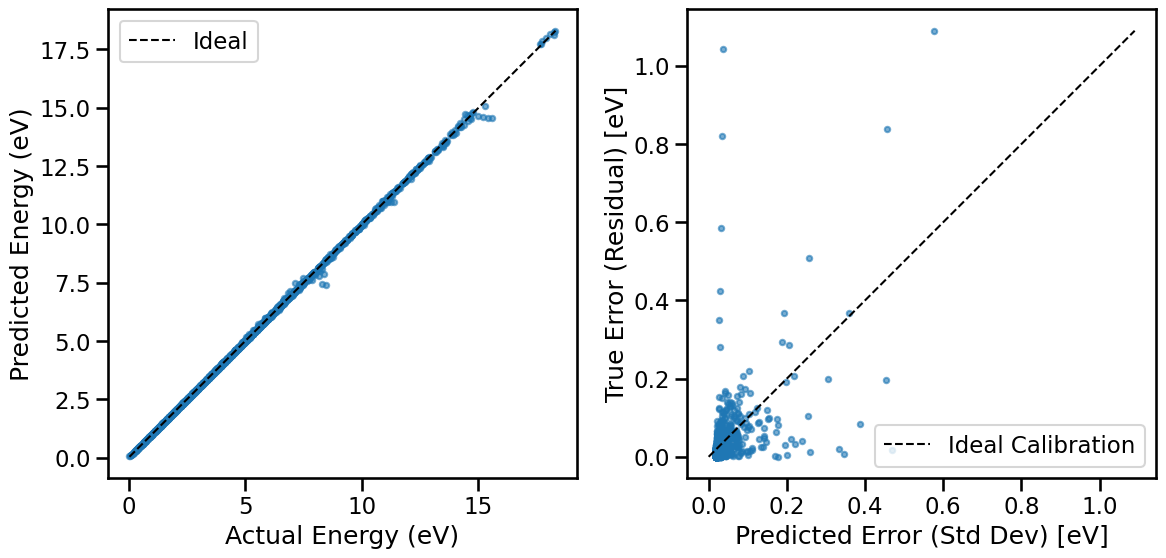

In [18]:
pred_std = jnp.sqrt(variance[N_train:])
true_error = jnp.abs(y_test - y_hat_tests)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Actual vs Predicted
ax1.scatter(y_test, y_hat_tests, alpha=0.6, s=15)
lims = [min(y_test.min(), y_hat_tests.min()), max(y_test.max(), y_hat_tests.max())]
ax1.plot(lims, lims, 'k--', lw=1.5, label="Ideal")
ax1.set_xlabel("Actual Energy (eV)")
ax1.set_ylabel("Predicted Energy (eV)")
ax1.set_aspect('equal')
ax1.legend()

# Plot 2: Model Uncertainty vs True Error
ax2.scatter(pred_std, true_error, alpha=0.6, s=15)
max_err = max(pred_std.max(), true_error.max())
ax2.plot([0, max_err], [0, max_err], 'k--', lw=1.5, label="Ideal Calibration")
ax2.set_xlabel("Predicted Error (Std Dev) [eV]")
ax2.set_ylabel("True Error (Residual) [eV]")
ax2.set_aspect('equal')
ax2.legend()

plt.tight_layout()
plt.show()

### Question 2.g

**Briefly discuss how accurate the Gaussian Process water model is. How accurate is the error prediction?** 

<div align="right">[5 points]</div>

The model is very accurate, with the predicted against actual energy plot showing near identical values for the ideal dashed line. The scatter plot lies with little residual about the $y=x$ ideal lie. The second subplot shows the error prediction is not properly calibrated; the model is accurate yet overconfident. Whilst most points have low uncertainty, there are several points with significant error. In turn, we can use this GP as a model for interpolation however the posterior variance shows the unreliability per sample.

### Question 3.a

**We now want to optimise the geometry of the water molecule, using our Gaussian Process energy model.**

This requires adjusting the atomic positions to minimise the energy. 

Complete the implementation of the function provided below to provide a wrapper function that generates the symmetrised descriptors and uses the GP model to predict the energy of the water molecule.

*Hint:* you can reuse your `descriptors()` function from above to map from an ASE Atoms object to the symmetrised descriptors, then use the `cond_gp.mean_function(desc)` method of the conditioned GP to predict the energy at new values of the descriptors.

<div align="right">[5 points]</div>

In [19]:
# build and condition a GP using training set and optimized parameters
log_prob, cond_gp = build_gp(learned_params, X_train).condition(y_train, diag=learned_params['noise_variance'])

# This is the wrapper function: Atoms object -> symmetrised descriptors -> GP prediction
def GP_water_energy(config: Atoms) -> float:
    description = descriptors(config)

    energy_prediction = cond_gp.mean_function(description)

    return float(energy_prediction)

In [20]:
from ase.build import molecule
assert abs(GP_water_energy(molecule('H2O')) - 0.015547806578943682) < 1e-4

We are now ready to relax the Cartesian coordinates of a water molecule, in order to find the equilibrium geometry. 

For simplicity, we first use the Nelder-Mead algorithm to find the minimum of the function, as it does not require access to the gradients. This requires the use of a further wrapper function to convert from a flat vector of 9 positions to an Atoms object suitable for passing to our `GP_water_energy()` function.

We start from a not-too crazy initial condition, and relax the position of all atoms.

In [21]:
from scipy.optimize import minimize

def wrapper(positions):
    atoms = molecule('H2O')
    atoms.positions[...] = positions.reshape((3, 3))
    return GP_water_energy(atoms)

x0 = np.array([0,0,0,       # Oxygen atom
               1.2,0,0,     # 1st hydrogen atom
               -0.5,0.7,0]) # 2nd hydrogen atom

res = minimize(wrapper, # function to minimise
               x0,              # initial condition
               method='nelder-mead',
               options={"maxiter":1000, # number of iterations in the minimiser
                        "fatol":1e-6,    # stopping criterion (tolerance)
                        "disp": True}
              )
# res.x contains the final configuration

Optimization terminated successfully.
         Current function value: 0.011184
         Iterations: 178
         Function evaluations: 308


### Question 3.b

Inspect the resulting water geometry. How realistic is it? You may wish to compute the bond lengths and angles and compare these geometrical parameters to literature (experimental and/or theoretical) values.

<div align="right">[5 points]</div>

In [22]:
optimised_molecule = molecule('H2O')
optimised_molecule.positions = res.x.reshape((3,3))

bond_length_1 = optimised_molecule.get_distance(0,1)
bond_length_2 = optimised_molecule.get_distance(0,2)
bond_angle = optimised_molecule.get_angle(1,0,2)

print(f"Optimised O-H1 Bond:  {bond_length_1:.4f} Å")
print(f"Optimised O-H2 Bond:  {bond_length_2:.4f} Å")
print(f"Optimised H-O-H Angle: {bond_angle:.2f}°")

view = nglview.show_ase(optimised_molecule)
view.add_representation("ball+stick")
view

Optimised O-H1 Bond:  0.9590 Å
Optimised O-H2 Bond:  0.9590 Å
Optimised H-O-H Angle: 104.51°


NGLWidget()

The resulting water geometry is very realistic. The optimised model is compared with values found in Császár et al.'s "On equilibrium structures of the water molecule" (https://doi.org/10.1063/1.1924506):

| Parameter | Your Optimized Model | Császár et al. (2005) Equilibrium |
| :--- | :--- | :--- |
| **Bond Length ($r_{\text{OH}}$)** | **0.9590 Å** | **0.9578 Å** |
| **Bond Angle ($\theta_{\text{HOH}}$)** | **104.51°** | **104.48°** |



### Extension Questions for Part 1

**Extension Question 1**

We can optimize the molecule much more quickly by taking advantage of two JAX features: (i) just-in-time compilation of the objective function with `jax.jit()`; (ii) automatic differentiation to provide gradients, allowing us to use the BFGS algorithm.

However, to do this you will need to reimplement the computation of the descriptors using JAX rather than numpy, and skip the ASE Atoms conversion step. Complete the code below and compare the number of steps taken to reach the solution.

**Key differences from the numpy/ASE version:**

1. Input is a flat JAX array of 9 elements (x,y,z for each of the 3 atoms), not an ASE Atoms object
2. Use `jnp.reshape()` to convert to a (3, 3) array of atom positions
3. Use `jnp.linalg.norm()` for distances and `jnp.dot()` for the dot product
4. The descriptor array can be shaped `(3,)` or `(1, 3)` for `cond_gp.mean_function()`

<div align="right">[10 points]</div>

In [23]:
from jax import Array

# Input: flat array of 9 elements [O_x, O_y, O_z, H1_x, H1_y, H1_z, H2_x, H2_y, H2_z]
# Output: scalar predicted energy
def GP_water_energy_jax(x: Array) -> Array:
    pass
    # come back here
    """
res = minimize(energy_wrapper,
               x0,
               method='bfgs',
               jac=grad_wrapper,
               options={"disp": True})

# Inspect the optimised geometry
atoms = molecule('H2O')
atoms.positions[...] = res.x.reshape((3, 3))
r1 = atoms.get_distance(0, 1)
r2 = atoms.get_distance(0, 2)
theta = atoms.get_angle(1, 0, 2)
print(f"\nOptimised geometry:")
print(f"r1 = {r1:.4f} Å, r2 = {r2:.4f} Å, angle = {theta:.1f}°")
print(f"BFGS converged in {res.nit} iterations (compare to ~50-100 for Nelder-Mead)")
    """


**Extension Question 2**

Try different kernels in the Gaussian Process regression.

<div align="right">[Not for credit]</div>

In [24]:
# YOUR CODE HERE
# raise NotImplementedError()

## Part 2 - Exploring Marginal Likelihood Landscapes

In Part 1, we used `gp_fit_restarts()` to optimise hyperparameters automatically. But what is this optimisation actually doing? How does the choice of hyperparameters affect the fit, and why might there be multiple local minima?

To understand this better, we'll work with a simpler 1D dataset where we can visualise the marginal likelihood as a function of the hyperparameters. This gives insight into:

- Why different hyperparameter choices lead to under/overfitting
- How the marginal likelihood balances data fit against model complexity
- Why optimisation can get stuck in local minima

We start by importing some data consisting of 7 $(x, y)$ pairs.

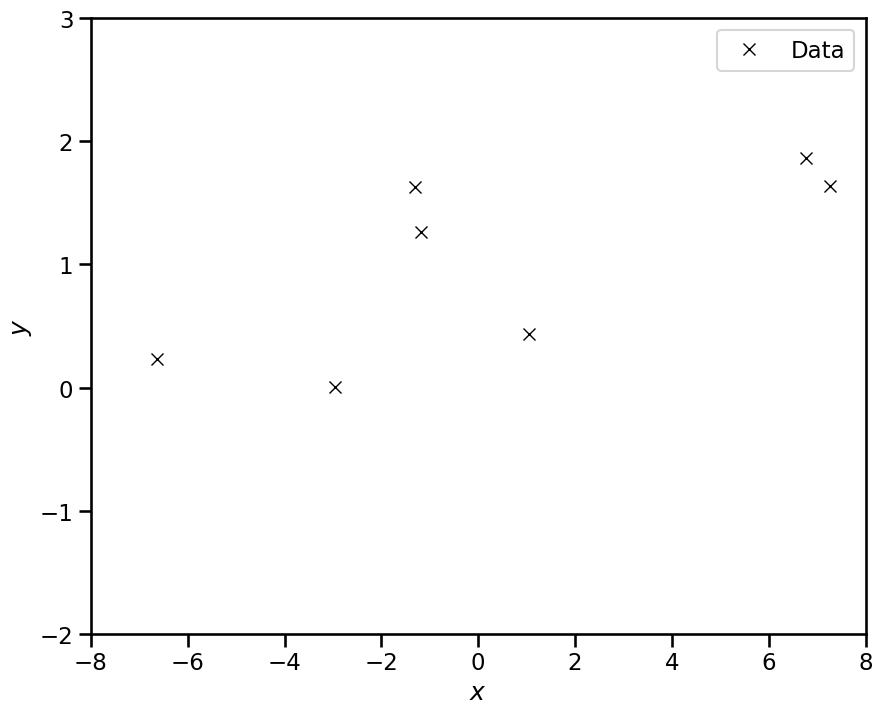

In [25]:
x_data, y_data = np.loadtxt('gpdata.csv', delimiter=',', skiprows=1).T
fig, ax = plt.subplots()
ax.plot(x_data, y_data, 'kx', label='Data')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_xlim(-8, 8)
ax.set_ylim(-2, 3)
ax.legend();

### Question 4.a

Produce plots to illustrate the results of fitting a GP with a squared exponential kernel to `(x_data, y_data)` using lengthscales of 0.3, 1.0 and 10 and $\sigma_n$ fixed at 0.1 and a signal variance fixed at 1.0. Annotate your plots with the log marginal likelihood of the data given the model.

You will need to write a `build_gp()` function similar to the one given in lectures and used in Part 1 above.

You may find the `gp_plot()` function from the lecture (which has been imported for you) useful, but you can also do your own plotting if you prefer.

<div align="right">[10 points]</div>

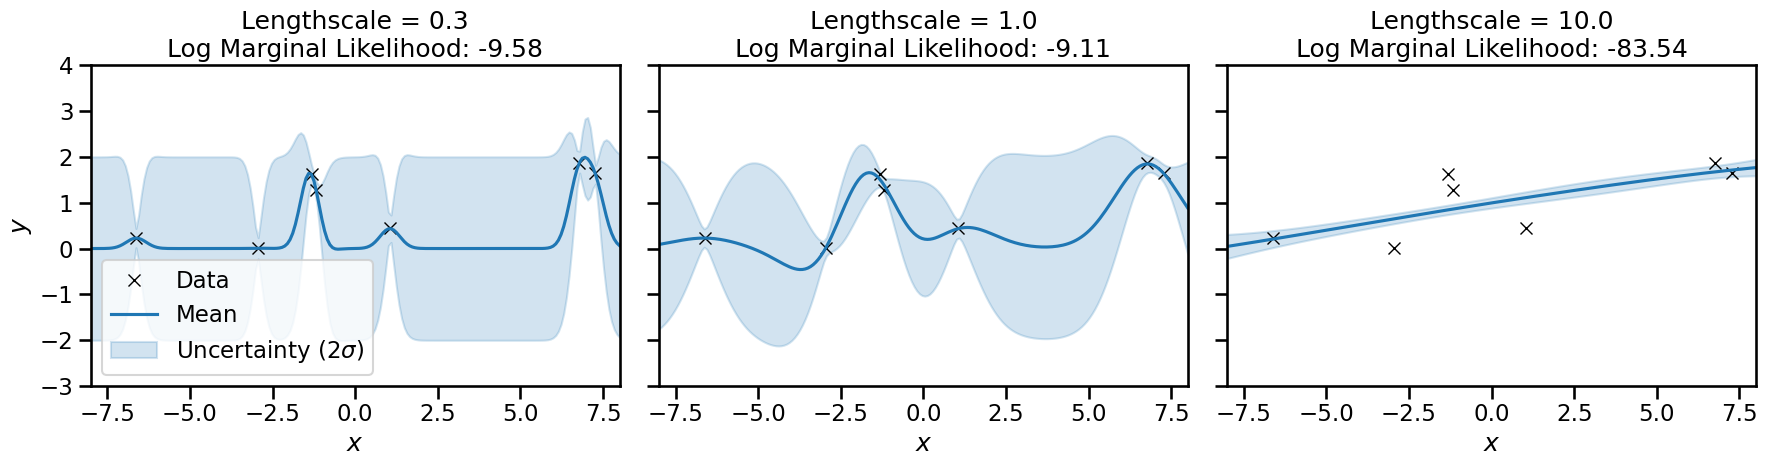

In [26]:
lengthscales = [0.3, 1.0, 10.0]
sigma_n = 0.1
noise_variance = sigma_n ** 2
signal_variance = 1.0

X_test = jnp.linspace(-8, 8, 200)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, l in enumerate(lengthscales):
    params = {
        'variance': signal_variance,
        'lengthscale': l,
        'noise_variance': noise_variance
    }
    
    gp = build_gp(params, x_data)
    cond_result = gp.condition(y_data, X_test)
    lml = cond_result.log_probability
    cond_gp = cond_result.gp
    

    mu = cond_gp.mean
    stdev = jnp.sqrt(cond_gp.variance)
    
    ax = axes[i]
    ax.plot(x_data, y_data, 'kx', label='Data')
    ax.plot(X_test, mu, color='C0', label='Mean')
    ax.fill_between(X_test, mu - 2*stdev, mu + 2*stdev, color='C0', alpha=0.2, label=rf'Uncertainty (2$\sigma$)')
    ax.set_title(f"Lengthscale = {l}\nLog Marginal Likelihood: {lml:.2f}")
    ax.set_xlabel('$x$')
    ax.set_xlim(-8, 8)
    ax.set_ylim(-3, 4)
    
    if i == 0:
        ax.set_ylabel('$y$')
        ax.legend(loc='lower left')

plt.tight_layout()
plt.show()

### Question 4.b

Comment on when are we underfitting, when are are overfitting. Does your visual impression match what the log marginal likelihood is indicating?

<div align="right">[5 points]</div>

The figure in Question 4.a. highlights the following:
*  There is significant overfitting for lengthscale $\ell = 0.3$; for small lengthscale, the model assumes the correlation between points decay fast, so between points, the model prediction goes back to the prior mean. The model does capture the underlying pattern but with large uncertainty. Whilst the log marginal likelihood is small, it is non-optimal of the lengthscale parameters available.
*  There is significant underfitting for large lengthscale $\ell = 10.0$; the regression curve is almost a straight line, identifying the true data as signal noise and ignoring it in the model prediction. In turn, it does not capture the underlying pattern. The log marginal likelihood in this case is -83.54, the worst of the three parameters, quantifying how poorly the model fits the data.

The visual impression matches what the log marginal likelihood is indicating.

### Question 4.c

**Produce a 2D contour map of the log marginal likelihood in the $(\ell, \sigma_n)$ landscape.**

Leave the signal variance fixed at 1.0.

In fact these data were generated as a sample from a GP with a squared exponential kernel with signal variance $\nu=1$, lengthscale $\ell=1.0$ and noise standard deviation $\sigma_n=0.1$. Show the hyperparameters of the generating GP as a point on your map.

*Hints:*

- Defining and just-in-time compiling (with `@jit`) a function which computes the log marginal likelihood for a given set of hyperparameters will speed up your code massively.
- Use logarithmic spacing for both axes (e.g., `jnp.logspace()`), since hyperparameters vary over orders of magnitude.
- Reasonable ranges to explore are $\ell \in [0.1, 100]$ and $\sigma_n \in [0.03, 3]$ - think about why these make sense given the data.
- Use `ax.set_xscale('log')` and `ax.set_yscale('log')` for better visualisation.

<div align="right">[10 points]</div>

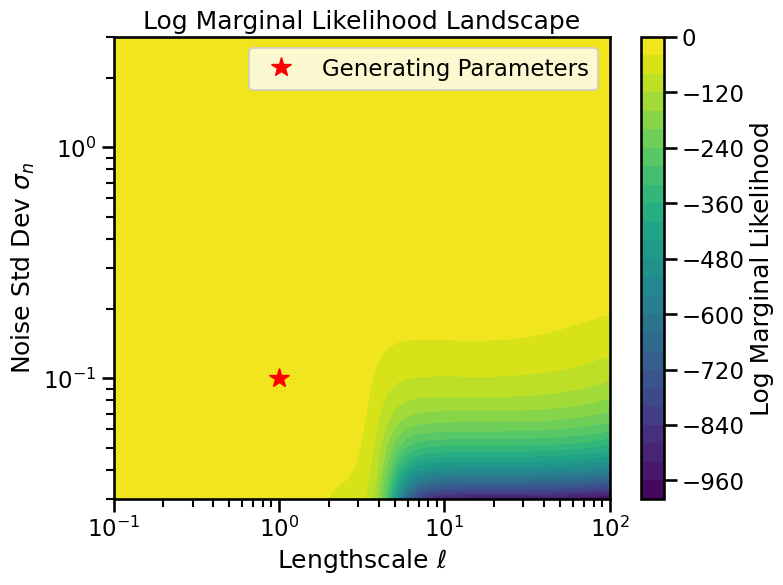

In [27]:
ell_vals = jnp.logspace(jnp.log10(0.1), jnp.log10(100), 50)
sig_vals = jnp.logspace(jnp.log10(0.03), jnp.log10(3), 50)
L_grid, S_grid = jnp.meshgrid(ell_vals, sig_vals)

@jit
def compute_lml(l, s):
    params = {
        'variance': 1.0,
        'lengthscale': l,
        'noise_variance': s**2
    }
    gp = build_gp(params, x_data)
    return gp.log_probability(y_data)

lml_vmap = vmap(vmap(compute_lml, in_axes=(0, 0)), in_axes=(0, 0))
Z_lml = lml_vmap(L_grid, S_grid)

fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(L_grid, S_grid, Z_lml, levels=30)
plt.colorbar(contour, label='Log Marginal Likelihood')

ax.plot(1.0, 0.1, 'r*', markersize=15, label='Generating Parameters')
ax.set_xscale('log')
ax.set_yscale('log')

# Added titles and labels
ax.set_xlabel(r'Lengthscale $\ell$')
ax.set_ylabel(r'Noise Std Dev $\sigma_n$')
ax.set_title(r'Log Marginal Likelihood Landscape')
ax.legend()

plt.show()

### Question 4.d

**Find the global minimum in the log marginal likelihood landscape.**

- Use the `gp_fit()` function from the `gputils` module (which has been imported for you) to optimise the $(\ell, \sigma_n)$ hyperparameters of the GP when conditioned on `(x_data, y_data)` (again, leave the signal variance fixed at 1.0)
- Choose an appropriate starting point by inspecting your log marginal likelihood plot above.
- Store the optimised parameter in a dictionary named `opt_params`
- Replot the contour map with the global minimum drawn on top. You might like to plot the generating and optimised GP models in the $(x,y)$ space as well.

<div align="right">[5 points for correct global minimum + 5 points for plot]    

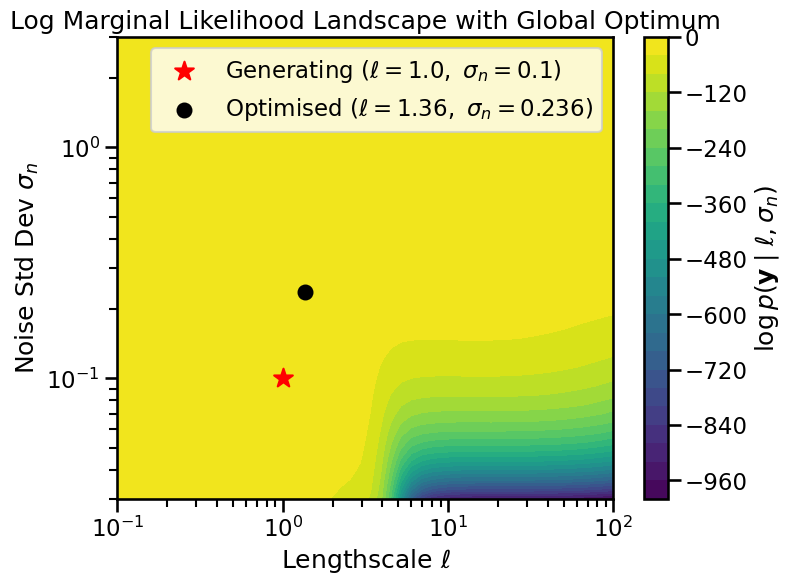

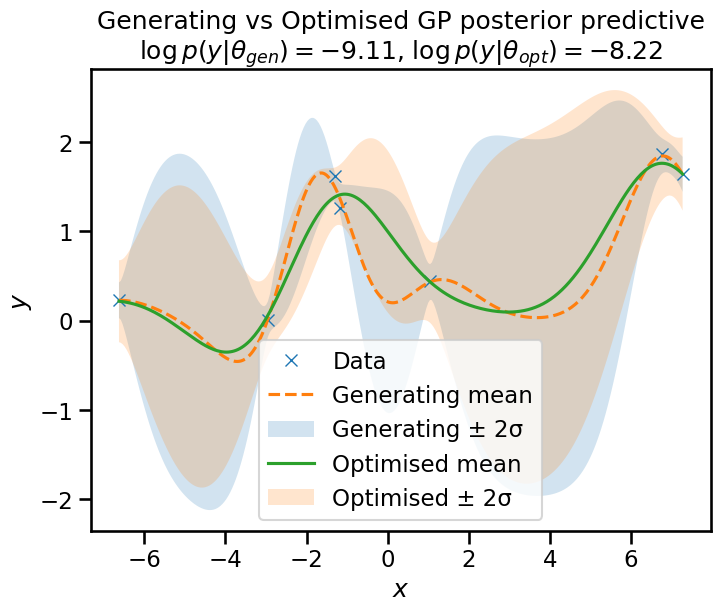

In [28]:
def fix_nu(theta):
    return {
        "variance": 1.0,
        "lengthscale": theta["lengthscale"],
        "noise_variance": theta["noise_variance"],
    }

def build_gp_fix_nu(theta, X):
    return build_gp(fix_nu(theta), X)

init_theta = {
    "lengthscale": 1.0,
    "noise_variance": 0.1**2,
}

neg_mll, theta_star = gp_fit(
    key,
    build_gp_fix_nu,
    x_data,
    y_data,
    init_theta,
)

opt_params = {
    "lengthscale": float(theta_star["lengthscale"]),
    "sigma_n": float(jnp.sqrt(theta_star["noise_variance"])),
    "noise_variance": float(theta_star["noise_variance"]),
}

# verify minima, should have opt_lml >= gen_lml
gen_lml = compute_lml(1.0, 0.1)
opt_lml = compute_lml(opt_params["lengthscale"], opt_params["sigma_n"])

#print("Generating log ML:", float(gen_lml))
#print("Optimised log ML:", float(opt_lml))

fig, ax = plt.subplots(figsize=(8, 6))

cf = ax.contourf(L_grid, S_grid, Z_lml, levels=30)
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(r"$\log p(\mathbf{y} \mid \ell,\sigma_n)$")

gen_label = r"Generating $(\ell=1.0,\ \sigma_n=0.1)$"
opt_label = rf"Optimised $(\ell={opt_params['lengthscale']:.3g},\ \sigma_n={opt_params['sigma_n']:.3g})$"

ax.scatter([1.0], [0.1], marker="*", s=200, color="red", label=gen_label)
ax.scatter([opt_params["lengthscale"]], [opt_params["sigma_n"]], marker="o", s=100, color="black", label=opt_label)


ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Lengthscale $\ell$")
ax.set_ylabel(r"Noise Std Dev $\sigma_n$")
ax.set_title("Log Marginal Likelihood Landscape with Global Optimum")
ax.legend()

plt.show()

# plot gp fits in (x,y) space
x_test = jnp.linspace(x_data.min(), x_data.max(), 300)

gen_params = {"variance": 1.0, "lengthscale": 1.0, "noise_variance": 0.1**2}

gp_gen = build_gp(gen_params, x_data)
gp_opt = build_gp(fix_nu(theta_star), x_data)

cond_gen = gp_gen.condition(y_data, x_test).gp
cond_opt = gp_opt.condition(y_data, x_test).gp

mu_gen = cond_gen.mean.squeeze()
sd_gen = jnp.sqrt(cond_gen.variance).squeeze()

mu_opt = cond_opt.mean.squeeze()
sd_opt = jnp.sqrt(cond_opt.variance).squeeze()

lml_gen = float(gp_gen.log_probability(y_data))
lml_opt = float(gp_opt.log_probability(y_data))

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x_data.squeeze(), y_data.squeeze(), "x", label="Data")

ax.plot(x_test, mu_gen, "--", label="Generating mean")
ax.fill_between(x_test.squeeze(), (mu_gen - 2 * sd_gen), (mu_gen + 2 * sd_gen), alpha=0.2, label="Generating ± 2σ")

ax.plot(x_test, mu_opt, "-", label="Optimised mean")
ax.fill_between(x_test.squeeze(), (mu_opt - 2 * sd_opt), (mu_opt + 2 * sd_opt), alpha=0.2, label="Optimised ± 2σ")

ax.set_title(
    "Generating vs Optimised GP posterior predictive\n"
    + rf"$\log p(y|\theta_{{gen}})={lml_gen:.2f}$, "
    + rf"$\log p(y|\theta_{{opt}})={lml_opt:.2f}$"
)

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.legend()
plt.show()

In [29]:
assert abs(opt_params['lengthscale'] - 1.35588062) < 1e-4
assert abs(opt_params['sigma_n'] - 0.23579831) < 1e-4

### Question 4.e

Does the global minimum match the hyperparameters used in the data generation? If not, why not?

<div align="right">[5 points]</div>

The global optimum of the log marginal likelihood does not match the hyperparameters used in the data generation. The observed vector $$\mathbf{y} = (y_1, ..., y_n)^\top$$ is an individual draw from the multivariate normal distribution $$\mathbf{y} \sim \mathcal{N}(0, K_{\theta_{gen}}(X, X) + \sigma^2_{n, gen}I)$$ where $X=(x_1,...,x_n).$ Through maximising the marginal likelihood $$\hat{\theta} = \arg \max \log p(\mathbf{y} \mid X, \ell, \sigma_n),$$ we are choosing hyperparameters that make the specific $\mathbf{y}$ vector probable under the GP model we've constructed. As $\mathbf{y}$ is random, $\hat{\theta}$ is also random, and even if the model was correct, finite sampling means $\hat{\theta}$ needn't equal $\theta_{gen}$: for a large sample size, we could expect $\hat{theta}$ to match the generating parameters.

**Extension Question 3**

Can you find and map out (all) other minima in the marginal likelihood landscape? Store a list of `params` dictionaries in a variable named `results`.

*Hint:* You could use `gp_fit_restarts()` with the `return_all=True` optional argument, or you could seed minimisations in different places based on a visual inspection of the landscape.

<div align="right">[10 points]</div>

Fit 1/25: 8.2210 (new global minimum) {'lengthscale': Array(1.35587936, dtype=float64), 'noise_variance': Array(0.05560078, dtype=float64)}
Fit 2/25: 8.7032  {'lengthscale': Array(12.65065756, dtype=float64), 'noise_variance': Array(0.36613207, dtype=float64)}
Fit 3/25: 8.2210  {'lengthscale': Array(1.35587958, dtype=float64), 'noise_variance': Array(0.05560083, dtype=float64)}
Fit 4/25: 8.2210 (new global minimum) {'lengthscale': Array(1.35587948, dtype=float64), 'noise_variance': Array(0.05560079, dtype=float64)}
Fit 5/25: 8.2210  {'lengthscale': Array(1.35587946, dtype=float64), 'noise_variance': Array(0.05560079, dtype=float64)}
Fit 6/25: 8.2210  {'lengthscale': Array(1.3558799, dtype=float64), 'noise_variance': Array(0.05560078, dtype=float64)}
Fit 7/25: 8.2210  {'lengthscale': Array(1.35587987, dtype=float64), 'noise_variance': Array(0.05560083, dtype=float64)}
Fit 8/25: 8.2210 (new global minimum) {'lengthscale': Array(1.35587945, dtype=float64), 'noise_variance': Array(0.055600

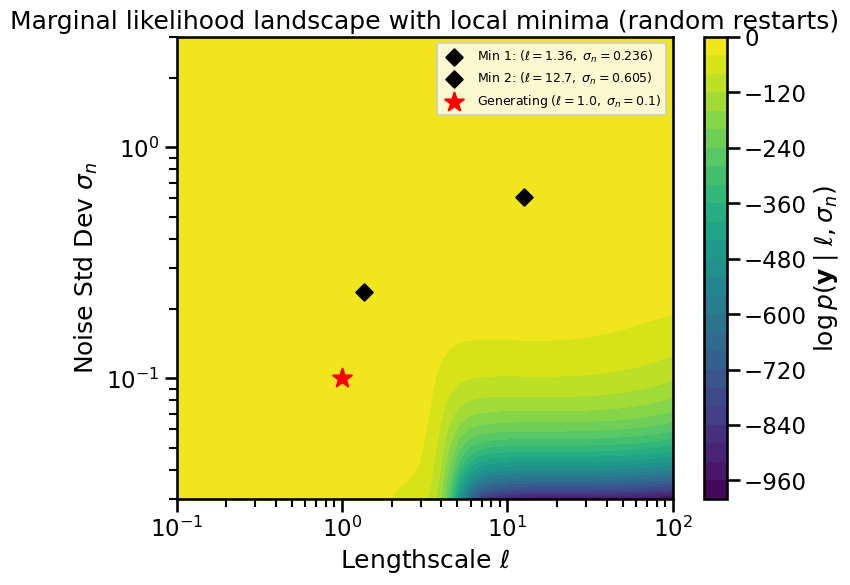

In [30]:
init_theta = {"lengthscale": 1.0, "noise_variance": 0.1**2}

all_fits = gp_fit_restarts(
    key,
    build_gp_fix_nu,
    x_data,
    y_data,
    init_theta,
    num_restarts=25,
    return_all=True,
    num_iters=300,
    gtol=1e-6,
)

candidates = []
for negative_mll, p in all_fits:
    candidates.append(
        {
            "lengthscale": float(p["lengthscale"]),
            "noise_variance": float(p["noise_variance"]),
            "sigma_n": float(jnp.sqrt(p["noise_variance"])),
            "neg_mll": float(negative_mll(p)),
        }
    )

candidates = sorted(candidates, key=lambda d: d["neg_mll"])

seen = set()
results = []

for d in candidates:
    log_ell = float(np.log10(d["lengthscale"]))
    log_sig = float(np.log10(d["sigma_n"]))
    k = (round(log_ell, 3), round(log_sig, 3))

    if k not in seen:
        seen.add(k)
        results.append({k2: d[k2] for k2 in ["lengthscale", "noise_variance", "sigma_n"]})

# plot distinct local optima
fig, ax = plt.subplots(figsize=(8, 6))

cf = ax.contourf(L_grid, S_grid, Z_lml, levels=30)
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(r"$\log p(\mathbf{y}\mid \ell,\sigma_n)$")

for i, d in enumerate(results, start=1):
    ell = d["lengthscale"]
    sig = d["sigma_n"]
    ax.scatter(
        [ell],
        [sig],
        marker="D",
        s=70,
        color="black",
        label=rf"Min {i}: $(\ell={ell:.3g},\ \sigma_n={sig:.3g})$",
    )

ax.scatter([1.0], [0.1], marker="*", s=200, color="red", label=r"Generating $(\ell=1.0,\ \sigma_n=0.1)$")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Lengthscale $\ell$")
ax.set_ylabel(r"Noise Std Dev $\sigma_n$")
ax.set_title("Marginal likelihood landscape with local minima (random restarts)")
ax.legend(loc="best", fontsize=9)

plt.show()

In [31]:
ell = [result['lengthscale'] for result in results]
sig = [result['sigma_n'] for result in results]

assert np.abs(np.sort(ell) - np.array([1.35588062, 12.65058736])).max() < 1e-4
assert np.abs(np.sort(sig) - np.array([0.23579831, 0.60508885])).max() < 1e-4

Before you submit this assignment, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill in any place that says YOUR CODE HERE or "YOUR ANSWER HERE".

# ES98E Assignment 4 - Gaussian Process regression

## Workshop Aims

* Data representation using invariant descriptors
* Uncertainty analysis of predicted energy values
* Optimising hyperparameters
* Exploring marginal likelihood landscapes

**Note**: *The maximum available points for this assignment is 120: 100 points for the core material that everyone is expected to attempt, and 20 points for extension material which is optional, but assessed. The highest percentage you could get on this assignment without attempting the extension material is 100/120 = 83.3%*

In [32]:
import numpy as np
import pandas as pd

from jax import jit, grad, vmap
import jax.numpy as jnp
import jax.random as jr
import tinygp
from jax import config
config.update("jax_enable_x64", True)     # use double rather than single precision floats
config.update('jax_platform_name', 'cpu') # use CPU rather than GPU

from gputils import gp_print, gp_plot, gp_fit, gp_fit_restarts

key = jr.PRNGKey(123)

from ase.io import read
from ase.build import molecule
import nglview

from IPython.display import display

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')

In [33]:
plt.rcParams["figure.figsize"] = (10, 8)

## Part 1
### Learning the interaction energy of a single water molecule

The quantum mechanical energy of a water molecule is a function of the geometry of the molecule, i.e. the Cartesian coordinates $\mathbf{r}_\rm{O}$, $\mathbf{r}_{\rm H_1}$ and  $\mathbf{r}_{\rm H_2}$. Of course, this energy does not depend on the orientation of the water molecule if there is no external field interacting with the molecule.

<img src="water.png">

We can rewrite the energy function as $E(\mathbf{r}_{\rm O},\mathbf{r}_{\rm H_1},\mathbf{r}_{\rm H_2}) \equiv E(r_{\rm OH_1},r_{\rm OH_2},\theta_{\rm HOH})$ where $r_{\rm OH}$ are the bond lengths and $\theta_{\rm HOH}$ the bond angle. This description is invariant to rotations and translations. We also know that the 'label' of the hydrogens is unimportant (i.e. swapping $\rm H_1$ and $\rm H_2$ does not change the energy), therefore it is useful to symmetrise the distances.

In this exercise, we will use the following data coordinates:
* $r_+ = r_{\rm OH_1} + r_{\rm OH_2}$
* $r_- = (r_{\rm OH_1} - r_{\rm OH_2})^2$
* $a = \mathbf{r}_{\rm OH_1} \cdot \mathbf{r}_{\rm OH_2}$

### Question 1.a

**Explain why making descriptor functions $r_+$, $r_-$ and $a$ invariant to physical symmetries is important, and how this is achieved here.**

Your answer should address:

1. **Why invariance matters**: What would happen if we used raw Cartesian coordinates $(\mathbf{r}_O, \mathbf{r}_{H_1}, \mathbf{r}_{H_2})$ as inputs to our ML model instead of invariant descriptors?

2. **Translation invariance**: Explain why $r_+$, $r_-$ and $a$ are unchanged if we shift the molecule by a constant vector $\mathbf{t}$.

3. **Rotation invariance**: Explain why $r_+$, $r_-$ and $a$ are unchanged if we rotate the molecule.

4. **Permutation invariance**: Explain why $r_+$, $r_-$ and $a$ are unchanged if we swap the labels of $\mathrm{H}_1$ and $\mathrm{H}_2$.

<div align="right">[5 points]</div>

YOUR ANSWER HERE

We now read in and visualise a dataset of 2886 water molecules, and compute the descriptors for each configuration.

In [34]:
water_configs = read("water_configs.xyz", format="extxyz", index=":")

# There should be 2886 independent water molecules
print(len(water_configs))

2886


In [35]:
nglview.show_asetraj(water_configs)

NGLWidget(max_frame=2885)

### Question 1.b

**Implement the three descriptors $r_+$, $r_-$ and $a$ defined above. Your function should take an ASE [Atoms](https://wiki.fysik.dtu.dk/ase/ase/atoms.html) object as input and return a numpy array of length 3.**

Hints:

- All configurations are ordered the same: O, H1, H2.
- Atomic positions can be accessed via the array `config.positions` which has shape `(N_atoms, 3)`, i.e. `(3, 3)` in this case, and distances between pairs of atoms can be computed with [ase.Atoms.get_distance()](https://wiki.fysik.dtu.dk/ase/ase/atoms.html#ase.Atoms.get_distance)
- The tests check that your code produces the expected values on a reference configuration.

<div align="right">[10 points]</div>

In [36]:
from ase import Atoms

def descriptors(config: Atoms) -> np.array:
    # YOUR CODE HERE
    raise NotImplementedError()

In [37]:
c = molecule('H2O')
c.positions = np.array([[ 0.16243454, -0.06117564,  0.06644482],
                        [-0.10729686,  0.84977976, -0.70720087],
                        [ 0.17448118, -0.83935969, -0.44514309]])

d1 = descriptors(c)
assert type(d1) == np.ndarray
assert len(d1) == 3
assert abs(d1 - [ 2.15656638,  0.08634174, -0.31635254]).max() < 1e-8

# also check a shifted cell
c.center()
d2 = descriptors(c)
assert abs(d1 - d2).max() < 1e-8

# and a rotated one
c.rotate(45, 'z')
d3 = descriptors(c)
assert abs(d1 - d3).max() < 1e-8

NotImplementedError: 

We now compute descriptors for the full dataset and store them in `x`, and collect the QM energies for the molecules in a vector `y`:

In [ ]:
x = [] # input features
y = [] # target values

# Calculate descriptor vectors for each molecule and collect target energies
for config in water_configs:
    x.append(descriptors(config))
    y.append(config.get_potential_energy()) # QM energy of a water molecule    

We randomly split the data to a train and test set. Note the use of a fixed random seed for reproducibilty.

In [ ]:
from sklearn.model_selection import train_test_split

# test_size sets the fraction of the test set
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.9, random_state=42) 

X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = np.array(X_test)
y_test = np.array(y_test)

print('Range of X inputs: {}'.format(X_train.max(axis=0) - X_train.min(axis=0)))
print("Range of Y values: {:.2f}".format(y_train.max()-y_train.min()))

### Question 2.a

Complete the implementation of a Gaussian process using `tinygp` as in the lecture. Use a squared exponential kernel in 3 dimensions and the values of the hyperparameters given in the `params` dictionary. 

*Hint:* Note that the [tinygp.transforms.Linear()](https://tinygp.readthedocs.io/en/latest/api/summary/tinygp.transforms.Linear.html#tinygp.transforms.Linear) takes the *inverse* lengthscale as the first argument, not the lengthscale; see the example in the lecture.

<div align="right">[5 points]</div>

In [ ]:
# we fix the hyperparameters initially
params = {'variance': 1.0, 
          'lengthscale': jnp.array([2.0, 2.0, 4.0]), 
          'noise_variance': 1.0}

def build_gp(params, X):
    # YOUR CODE HERE
    raise NotImplementedError()

In [ ]:
gp = build_gp(params, X_train)

assert type(gp) == tinygp.gp.GaussianProcess
assert type(gp.kernel) == tinygp.kernels.base.Product
assert type(gp.kernel.kernel1) == tinygp.kernels.base.Constant
assert gp.kernel.kernel1.value == params['variance']

assert type(gp.kernel.kernel2) == tinygp.transforms.Linear
assert np.abs(gp.kernel.kernel2.scale - 1.0 / params['lengthscale']).max() < 1e-6
assert type(gp.kernel.kernel2.kernel) == tinygp.kernels.stationary.ExpSquared

assert abs(gp.log_probability(y_train) - -1150.46204946) < 1e-3

### Question 2.b

**Condition your Gaussian Process on the training data.**

You must name the conditioned GP object `cond_gp` to pass the tests below.

Hints:

- Use your `build_gp()` to build a GP with the given hyperparameters and inputs `X_train`, and then use its `.condition()` method to condition it on the target values `y_train`.
- You need to provide the estimated noise variance from `params['noise_variance']` via the `diag` argument to [tinygp.GaussianProcess.condition()](https://tinygp.readthedocs.io/en/latest/api/summary/tinygp.GaussianProcess.html#tinygp.GaussianProcess.condition). Leaving this out would imply there is no noise on your training data.
- **Important**: Call `.condition(y_train, diag=...)` *without* passing an `X_test` argument. This returns a conditioned GP that can later make predictions at any test points using its `.mean_function()` method (used in Q3.a).

<div align="right">[5 points]</div>

In [ ]:
params = {'variance': 1.0, 
          'lengthscale': jnp.array([2.0, 2.0, 4.0]), 
          'noise_variance': 1.0}

# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
assert type(cond_gp) == tinygp.gp.GaussianProcess
assert abs(cond_gp.log_probability(y_train) - -878.58392128) < 1e-4

### Question 2.c

**Optimise the marginal likelihood with respect to the hyperparameters of the model.**

- Use the `gp_fit_restarts()` utility function from the lecture (this has already been imported for you at the top of this notebook from the [gputils](gputils.py) module) with the given initial guesses for the hyperparameters
- Assign the results to `negative_mll` and `learned_params`, for the objective function (negative log marginal likelihood) and the optimised parameter values, respectively.
- The variance has been estimated from the range (squared) of the function values, and lengthscales from the range of variation along each input dimension.

<div align="right">[5 points]</div>

In [ ]:
params = {'variance': 1.0, 
          'lengthscale': jnp.array([2.0, 2.0, 4.0]), 
          'noise_variance': 1.0}

# YOUR CODE HERE
raise NotImplementedError()

Use the code below to print out the results of the fit. You should verify that all parameter gradients are small at the end of the optimisations (with the exception of the observation noise, see Q2.e below), indicating a good fit. Your code should also pass the test below.

In [ ]:
gp_print(learned_params, negative_mll)

In [ ]:
assert abs(negative_mll(learned_params) - -288.5489) < 1e-4

`learned_params` contains the hyper-parameters of the trained model. The GP as a whole is a combination of the _prior_ (in the form of the kernel and its hyperparameters, as well as the noise model) and _data_ (in the form of geometrical descriptors and corresponding energy values).

### Question 2.d

**From the output above, what is the noise variance of the optimised model? What does this tell us about the data?** 

<div align="right">[5 points]</div>

YOUR ANSWER HERE

### Question 2.e

**Use the model to predict the energies for both training and test data, and compute the test RMSE (root mean squared error) in units of meV/atom**

- Build a new GP with the learned hyperparameters, condition it on `y_train`, and pass **both** `X_train` and `X_test` (stacked together with `jnp.vstack()`) to the `gp.condition()` method. This gives predictions at all points, allowing you to compare training and test performance in Q2.f.
- Extract the predicted mean and variance for both sets by slicing the conditioned GP's `.mean` and `.variance` arrays using `N_train = len(X_train)`.
- Compute the test RMSE and store it in a variable `rmse`.
- For the units conversion, note that 1000 meV = 1 eV, and that the per-atom energy requires dividing the energy by the number of atoms (3 in this case).

<div align="right">[5 points]</div>

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
assert abs(rmse - 17.47) < 1e-2
assert abs(cond_gp.variance.sum() - 4.6107) < 1e-2

### Question 2.f

**Plot graphs to show the correlation of actual and predicted energies, and of the actual and predicted error**

Here the "predicted error" is the GP posterior standard deviation, $\sqrt{V_*}$, where $V_*$ is the posterior variance at each test point. This represents the model's uncertainty in its prediction (a 1$\sigma$ error bar). In the second plot, compare this against the true error $|y_{\rm true} - y_{\rm pred}|$.

Take care to format these plots well; for example aspect ratio should be fixed to 1:1 so that the ideal model would be a line at an angle of 45$^\circ$ to the axes.

<div align="right">[5 points]</div>

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

### Question 2.g

**Briefly discuss how accurate the Gaussian Process water model is. How accurate is the error prediction?** 

<div align="right">[5 points]</div>

YOUR ANSWER HERE

### Question 3.a

**We now want to optimise the geometry of the water molecule, using our Gaussian Process energy model.**

This requires adjusting the atomic positions to minimise the energy. 

Complete the implementation of the function provided below to provide a wrapper function that generates the symmetrised descriptors and uses the GP model to predict the energy of the water molecule.

*Hint:* you can reuse your `descriptors()` function from above to map from an ASE Atoms object to the symmetrised descriptors, then use the `cond_gp.mean_function(desc)` method of the conditioned GP to predict the energy at new values of the descriptors.

<div align="right">[5 points]</div>

In [ ]:
# build and condition a GP using training set and optimized parameters
log_prob, cond_gp = build_gp(learned_params, X_train).condition(y_train, diag=learned_params['noise_variance'])

# This is the wrapper function: Atoms object -> symmetrised descriptors -> GP prediction
def GP_water_energy(config: Atoms) -> float:
    # YOUR CODE HERE
    raise NotImplementedError()

In [ ]:
from ase.build import molecule
assert abs(GP_water_energy(molecule('H2O')) - 0.015547806578943682) < 1e-4

We are now ready to relax the Cartesian coordinates of a water molecule, in order to find the equilibrium geometry. 

For simplicity, we first use the Nelder-Mead algorithm to find the minimum of the function, as it does not require access to the gradients. This requires the use of a further wrapper function to convert from a flat vector of 9 positions to an Atoms object suitable for passing to our `GP_water_energy()` function.

We start from a not-too crazy initial condition, and relax the position of all atoms.

In [ ]:
from scipy.optimize import minimize

def wrapper(positions):
    atoms = molecule('H2O')
    atoms.positions[...] = positions.reshape((3, 3))
    return GP_water_energy(atoms)

x0 = np.array([0,0,0,       # Oxygen atom
               1.2,0,0,     # 1st hydrogen atom
               -0.5,0.7,0]) # 2nd hydrogen atom

res = minimize(wrapper, # function to minimise
               x0,              # initial condition
               method='nelder-mead',
               options={"maxiter":1000, # number of iterations in the minimiser
                        "fatol":1e-6,    # stopping criterion (tolerance)
                        "disp": True}
              )
# res.x contains the final configuration

### Question 3.b

Inspect the resulting water geometry. How realistic is it? You may wish to compute the bond lengths and angles and compare these geometrical parameters to literature (experimental and/or theoretical) values.

<div align="right">[5 points]</div>

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

YOUR ANSWER HERE

### Extension Questions for Part 1

**Extension Question 1**

We can optimize the molecule much more quickly by taking advantage of two JAX features: (i) just-in-time compilation of the objective function with `jax.jit()`; (ii) automatic differentiation to provide gradients, allowing us to use the BFGS algorithm.

However, to do this you will need to reimplement the computation of the descriptors using JAX rather than numpy, and skip the ASE Atoms conversion step. Complete the code below and compare the number of steps taken to reach the solution.

**Key differences from the numpy/ASE version:**

1. Input is a flat JAX array of 9 elements (x,y,z for each of the 3 atoms), not an ASE Atoms object
2. Use `jnp.reshape()` to convert to a (3, 3) array of atom positions
3. Use `jnp.linalg.norm()` for distances and `jnp.dot()` for the dot product
4. The descriptor array can be shaped `(3,)` or `(1, 3)` for `cond_gp.mean_function()`

<div align="right">[10 points]</div>

In [ ]:
from jax import Array

# Input: flat array of 9 elements [O_x, O_y, O_z, H1_x, H1_y, H1_z, H2_x, H2_y, H2_z]
# Output: scalar predicted energy
def GP_water_energy_jax(x: Array) -> Array:
    # YOUR CODE HERE
    raise NotImplementedError()
    return energy

# Run BFGS optimization with JIT-compiled function and autodiff gradients
res = minimize(jit(GP_water_energy_jax),            # JIT-compiled objective
               x0,                                   # initial condition from above
               method='bfgs',
               jac=jit(grad(GP_water_energy_jax)),  # JIT-compiled gradient via autodiff
               options={"disp": True})

# Inspect the optimised geometry
atoms = molecule('H2O')
atoms.positions[...] = res.x.reshape((3, 3))
r1 = atoms.get_distance(0, 1)
r2 = atoms.get_distance(0, 2)
theta = atoms.get_angle(1, 0, 2)
print(f"\nOptimised geometry:")
print(f"r1 = {r1:.4f} Å, r2 = {r2:.4f} Å, angle = {theta:.1f}°")
print(f"BFGS converged in {res.nit} iterations (compare to ~50-100 for Nelder-Mead)")

**Extension Question 2**

Try different kernels in the Gaussian Process regression.

<div align="right">[Not for credit]</div>

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

## Part 2 - Exploring Marginal Likelihood Landscapes

In Part 1, we used `gp_fit_restarts()` to optimise hyperparameters automatically. But what is this optimisation actually doing? How does the choice of hyperparameters affect the fit, and why might there be multiple local minima?

To understand this better, we'll work with a simpler 1D dataset where we can visualise the marginal likelihood as a function of the hyperparameters. This gives insight into:

- Why different hyperparameter choices lead to under/overfitting
- How the marginal likelihood balances data fit against model complexity
- Why optimisation can get stuck in local minima

We start by importing some data consisting of 7 $(x, y)$ pairs.

In [ ]:
x_data, y_data = np.loadtxt('gpdata.csv', delimiter=',', skiprows=1).T
fig, ax = plt.subplots()
ax.plot(x_data, y_data, 'kx', label='Data')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_xlim(-8, 8)
ax.set_ylim(-2, 3)
ax.legend();

### Question 4.a

Produce plots to illustrate the results of fitting a GP with a squared exponential kernel to `(x_data, y_data)` using lengthscales of 0.3, 1.0 and 10 and $\sigma_n$ fixed at 0.1 and a signal variance fixed at 1.0. Annotate your plots with the log marginal likelihood of the data given the model.

You will need to write a `build_gp()` function similar to the one given in lectures and used in Part 1 above.

You may find the `gp_plot()` function from the lecture (which has been imported for you) useful, but you can also do your own plotting if you prefer.

<div align="right">[10 points]</div>

In [ ]:
def build_gp_opt(params, X):
    kernel = 1.0 * tinygp.kernels.ExpSquared(scale=params['lengthscale'])
    return tinygp.GaussianProcess(kernel, X, diag=params['sigma_n']**2)

init_params = {
    "lengthscale": 1.0,
    "sigma_n": 0.5
}

key = jax.random.PRNGKey(42)
neg_mll, opt_params = gp_fit(key, build_gp_opt, x_data, y_data, init_params)

ell_vals = jnp.logspace(jnp.log10(0.1), jnp.log10(100), 50)
sig_vals = jnp.logspace(jnp.log10(0.03), jnp.log10(3), 50)
L_grid, S_grid = jnp.meshgrid(ell_vals, sig_vals)

@jit
def compute_lml(l, s):
    params = {'lengthscale': l, 'sigma_n': s}
    gp = build_gp_opt(params, x_data)
    return gp.log_probability(y_data)

lml_vmap = vmap(vmap(compute_lml, in_axes=(0, 0)), in_axes=(0, 0))
Z_lml = lml_vmap(L_grid, S_grid)

fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(L_grid, S_grid, Z_lml, levels=30)
plt.colorbar(contour, label='Log Marginal Likelihood')

ax.plot(1.0, 0.1, 'r*', markersize=15, label='Generating GP')
ax.plot(opt_params['lengthscale'], opt_params['sigma_n'], 'w*', markersize=15, markeredgecolor='k', label='Global Minimum')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Lengthscale $\ell$')
ax.set_ylabel(r'Noise Std Dev $\sigma_n$')
ax.set_title('Log Marginal Likelihood Landscape')
ax.legend()

plt.show()

### Question 4.b

Comment on when are we underfitting, when are are overfitting. Does your visual impression match what the log marginal likelihood is indicating?

<div align="right">[5 points]</div>

YOUR ANSWER HERE

### Question 4.c

**Produce a 2D contour map of the log marginal likelihood in the $(\ell, \sigma_n)$ landscape.**

Leave the signal variance fixed at 1.0.

In fact these data were generated as a sample from a GP with a squared exponential kernel with signal variance $\nu=1$, lengthscale $\ell=1.0$ and noise standard deviation $\sigma_n=0.1$. Show the hyperparameters of the generating GP as a point on your map.

*Hints:*

- Defining and just-in-time compiling (with `@jit`) a function which computes the log marginal likelihood for a given set of hyperparameters will speed up your code massively.
- Use logarithmic spacing for both axes (e.g., `jnp.logspace()`), since hyperparameters vary over orders of magnitude.
- Reasonable ranges to explore are $\ell \in [0.1, 100]$ and $\sigma_n \in [0.03, 3]$ - think about why these make sense given the data.
- Use `ax.set_xscale('log')` and `ax.set_yscale('log')` for better visualisation.

<div align="right">[10 points]</div>

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

### Question 4.d

**Find the global minimum in the log marginal likelihood landscape.**

- Use the `gp_fit()` function from the `gputils` module (which has been imported for you) to optimise the $(\ell, \sigma_n)$ hyperparameters of the GP when conditioned on `(x_data, y_data)` (again, leave the signal variance fixed at 1.0)
- Choose an appropriate starting point by inspecting your log marginal likelihood plot above.
- Store the optimised parameter in a dictionary named `opt_params`
- Replot the contour map with the global minimum drawn on top. You might like to plot the generating and optimised GP models in the $(x,y)$ space as well.

<div align="right">[5 points for correct global minimum + 5 points for plot]    

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
assert abs(opt_params['lengthscale'] - 1.35588062) < 1e-4
assert abs(opt_params['sigma_n'] - 0.23579831) < 1e-4

### Question 4.e

Does the global minimum match the hyperparameters used in the data generation? If not, why not?

<div align="right">[5 points]</div>

YOUR ANSWER HERE

**Extension Question 3**

Can you find and map out (all) other minima in the marginal likelihood landscape? Store a list of `params` dictionaries in a variable named `results`.

*Hint:* You could use `gp_fit_restarts()` with the `return_all=True` optional argument, or you could seed minimisations in different places based on a visual inspection of the landscape.

<div align="right">[10 points]</div>

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
ell = [result['lengthscale'] for result in results]
sig = [result['sigma_n'] for result in results]

assert np.abs(np.sort(ell) - np.array([1.35588062, 12.65058736])).max() < 1e-4
assert np.abs(np.sort(sig) - np.array([0.23579831, 0.60508885])).max() < 1e-4